<a href="https://colab.research.google.com/github/Ruturaj2472/LangGraph_Agent/blob/main/LangGraph_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LangGraph is a library for building stateful, multi-actor applications with LLMs, used to create agent and multi-agent workflows. Compared to other LLM frameworks, it offers these core benefits: cycles, controllability, and persistence. LangGraph allows you to define flows that involve cycles, essential for most agentic architectures, differentiating it from DAG-based solutions. As a very low-level framework, it provides fine-grained control over both the flow and state of your application, crucial for creating reliable agents. Additionally, LangGraph includes built-in persistence, enabling advanced human-in-the-loop and memory features.

Source: LangGraph Github

In [1]:
!pip install langgraph langchain_openai openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 15.5 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.3
    Uninstalling langchain-core-1.6.3:
      Successfully uninstalled langchain-core-1.6.3


In [2]:
!pip install tavily-python langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
import os
from google.colab import userdata
OpenAI_API = userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = OpenAI_API

## Single LLM Agent

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Begin by creating a StateGraph. A StateGraph object outlines the structure of the chatbot as a "state machine."
# We'll incorporate nodes to represent the LLM and the functions that the agent can invoke,
# while edges will define how the agent transitions between these functions.

class State(TypedDict):
    messages: Annotated[list, add_messages]

# Each node can receive the current State as input and output an update to the state.
graph_builder = StateGraph(State)

In [5]:
# Load the LLM
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

# Create LLM invoke function
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# Creating first node

graph_builder.add_node("chatbot", chatbot)

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever the node is used.

Observe that the node receives the current State as input and returns a dictionary with an updated "messages" list. This is the standard pattern for all LangGraph node functions.

The add_messages function in our State appends the LLM's response messages to the existing messages in the state.









In [6]:
# creating edges


graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [7]:
# Finally, to execute the graph, call the compile() method on the graph builder.
# This will prepare the graph for execution.
# This generates a CompiledGraph that can be invoked on our state, allowing us to execute the graph's defined workflow.
graph = graph_builder.compile()

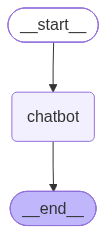

In [8]:
# Display the Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
# Passing a input to test the Agent

user_input = "What do you know about AI?"
print("User: " + user_input)

for event in graph.stream({"messages": [("user", user_input)]}):
  for value in event.values():
    print("Assistant:", value["messages"][-1].content)

User: What do you know about AI?
Assistant: Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, especially computer systems. These processes include learning (the acquisition of information and rules for using it), reasoning (using rules to reach approximate or definite conclusions), and self-correction. Below are some key concepts related to AI:

1. **Types of AI**:
   - **Narrow AI (Weak AI)**: Systems designed and trained for specific tasks, such as voice assistants like Siri or Alexa, recommendation algorithms, and image recognition software.
   - **General AI (Strong AI)**: A theoretical type of AI that possesses the ability to understand, learn, and apply intelligence in a general, human-like manner. This level of AI does not yet exist.

2. **Machine Learning**: A subset of AI where algorithms improve their performance on a task over time with experience. It includes various techniques like supervised learning, unsupervised learning,

## Adding tools to this Simple Agent

We will using Tavily search engine. Get tavily API key from https://tavily.com/

In [10]:
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

In [11]:
# tavily is available from langchain community library
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]

# testing
tool.invoke("What is ML?")

/tmp/ipykernel_1263/223192724.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
/tmp/ipykernel_1263/223192724.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


[{'title': 'Machine learning - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Machine_learning',
  'content': 'Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks "Task (computing)") without being explicitly programmed.\n\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\n\nFrom a theoretical viewpoint, probably approximately correct learning provides a mathematical and statistical framework for describing machine learning. Most traditional machine learning and deep learning algorithms can be described as empirical risk minimisation under this framework. [...] Machine learning (ML), reorganised and recognised as its own field, started to flourish in the 1990s. Th

In [12]:
from langgraph.prebuilt import ToolNode, tools_condition

# ToolNode -> A node that runs the tools called in the last AIMessage.
# It can be used either in StateGraph with a "messages" state key (or a custom key passed via ToolNode's 'messages_key').
# If multiple tool calls are requested, they will be run in parallel.
# The output will be a list of ToolMessages, one for each tool call.


# tools_condition -> Use in the conditional_edge to route to the ToolNode if the last message has tool calls.
# Otherwise, route to the end.

In [13]:
# New Agent

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=2)
tools = [tool]
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile()

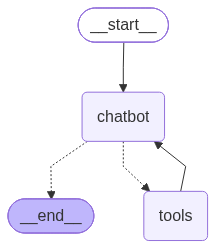

In [14]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
# Passing a input to test the Agent with tool calling

user_input = "What do you know about AI?"
print("User: " + user_input)

for event in graph.stream({"messages": [("user", user_input)]}):
  for value in event.values():
    print("Assistant:", value["messages"][-1].content)

User: What do you know about AI?
Assistant: Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. Here are some key points about AI:

1. **Types of AI**:
   - **Narrow AI**: Also known as weak AI, this type performs specific tasks and is the most common form of AI in use today, such as virtual assistants (like Siri or Alexa) and recommendation systems (like those used by Netflix or Amazon).
   - **General AI**: Also known as strong AI, this is a theoretical form of AI that has the ability to understand, learn, and apply intelligence broadly, much like a human.

2. **Machine Learning (ML)**: A subset of AI, machine learning involves algorithms that allow computers to learn from and make predictions based on data. This includes techniques like supervised learning, unsupervised learning, and reinforcement learning.

3. **Deep Learning**: A further subset of machine learning that uses neural networks with

## Add memory to the Agent


In [16]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

Currently using an memory checkpointer. This is limited till experimentations but in a production application, you should switch to use SqliteSaver or PostgresSaver and connect to your own DB to store the chat memory of graph.

In [17]:
# Building the Agent with Memory

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=2)
tools = [tool]
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

graph = graph_builder.compile(checkpointer=memory)

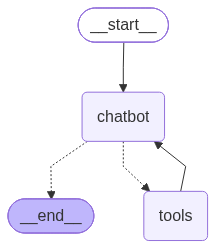

In [18]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [19]:
config = {"configurable": {"thread_id": "User_1"}}

user_input = "Hi, my name is Ruturaj"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Ruturaj
================================== Ai Message ==================================

Hello Ruturaj! How can I assist you today?


In [20]:
user_input = "Do you know my name?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you know my name?
================================== Ai Message ==================================

Yes, your name is Ruturaj. How can I help you today?


### What would happen if I change my config

In [21]:
config = {"configurable": {"thread_id": "User_2"}}

user_input = "Do you know my name?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you know my name?
================================== Ai Message ==================================

No, I don't know your name. However, if you'd like to share it or if you have any specific questions or tasks, feel free to let me know!


As expected, as the thread id has changed, it doesn't have access to memory of other thread

## Snapshot of current state

In [22]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Do you know my name?', additional_kwargs={}, response_metadata={}, id='6769f091-708e-4c34-a34e-b536f66cf31d'), AIMessage(content="No, I don't know your name. However, if you'd like to share it or if you have any specific questions or tasks, feel free to let me know!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 85, 'total_tokens': 119, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b494cd1199', 'id': 'chatcmpl-ETxXBD96MlggwMKtAwPK8xJhSCbDN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0f489-d06c-7df0-bd76-aeade4a5efbc-0', tool_calls=[], invalid

## Multi LLM Agent Flow

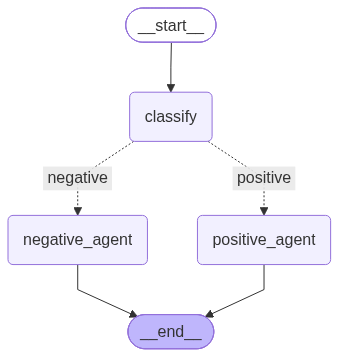

In [23]:
from langchain_core.prompts import PromptTemplate

def classify_feedback(state):
    llm = ChatOpenAI()
    prompt = PromptTemplate.from_template("""
    You are a sentiment analysis agent. You need to classify the following feedback as either positive or negative.

    Feedback: {input}

    Your answer (positive/negative):
    """)
    chain = prompt | llm
    response = chain.invoke({"input": state["input"]})
    sentiment = response.content.strip().lower()
    return {"sentiment": sentiment, "input": state["input"]}

# Handling positive feedback with a thank-you message
def handle_positive_feedback(state):
    llm = ChatOpenAI()
    prompt = PromptTemplate.from_template(
        "Thank the customer for their positive feedback: {input}"
    )
    chain = prompt | llm
    response = chain.invoke({"input": state["input"]})
    return {"output": response}

# Handling negative feedback with an apology and improvement promise
def handle_negative_feedback(state):
    llm = ChatOpenAI()
    prompt = PromptTemplate.from_template(
        "Apologize to the customer and assure them that the issue will be addressed: {input}"
    )
    chain = prompt | llm
    response = chain.invoke({"input": state["input"]})
    return {"output": response}

# Defining the agent state
# Check how there is a change in the functions above where we have specifically used input, output and sentiment
class AgentState(TypedDict):
    input: str
    output: str
    sentiment: str

# Creating the workflow
workflow = StateGraph(AgentState)

workflow.add_node("classify", classify_feedback)
workflow.add_node("positive_agent", handle_positive_feedback)
workflow.add_node("negative_agent", handle_negative_feedback)

workflow.add_conditional_edges(
    "classify",
    lambda x: x["sentiment"],
    {
        "positive": "positive_agent",
        "negative": "negative_agent"
    }
)

workflow.set_entry_point("classify")
workflow.add_edge("positive_agent", END)
workflow.add_edge("negative_agent", END)
workflow.compile()

In [24]:
def get_feedback(user_input):
  events = graph.stream(
      {"messages": [("user", user_input)]}, config, stream_mode="values"
  )

  for event in events:
      event["messages"][-1].pretty_print()

user_inputs = ["I absolutely loved the service! The staff were friendly, and everything went smoothly. I'll definitely come back!",
            "The service was slow, and the staff seemed disinterested. I had to wait much longer than expected.",
            "My experience was frustrating. The website was hard to navigate, and I couldn't find the information I needed."]

for input in user_inputs:
  get_feedback(input)
  print("\n")

================================ Human Message =================================

I absolutely loved the service! The staff were friendly, and everything went smoothly. I'll definitely come back!
================================== Ai Message ==================================

It sounds like you had a great experience! Would you like to share any details about the service or venue you visited? Additionally, if you need assistance with anything related to your experience or future plans, feel free to let me know!


================================ Human Message =================================

The service was slow, and the staff seemed disinterested. I had to wait much longer than expected.
================================== Ai Message ==================================

I'm sorry to hear that your experience was disappointing. Slow service and a lack of engagement from staff can be frustrating. If you'd like to provide feedback to the establishment or seek a resolution, I can assist 